# **03_ML Medical No-show**

# Section 1 - Notebook Objective and Modelling Goal

This notebook develops and evaluates machine learning models to predict whether a patient is likely to miss their appointment.

The modelling stage builds on the cleaned dataset created during ETL and the key patterns identified during EDA. The aim is to compare a simple baseline model with a more flexible comparison model and identify which approach is more suitable for this business problem.

From an operational perspective, this type of model could help healthcare providers better understand no-show risk and support more targeted intervention planning.

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\ryan_\\VS-code-projects\\medical-appointment-no-show-analytics\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\ryan_\\VS-code-projects\\medical-appointment-no-show-analytics'

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# notebook display settings
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# Section 2 - Load and Review Modelling Dataset

In this section, the cleaned dataset is loaded and checked before modelling begins.

The purpose of this step is to confirm that the correct version of the dataset is being used, review its overall shape, and make sure the expected columns from ETL and EDA are available for modelling.

In [5]:
#Load cleaned dataset from 01_ETL.ipynb

file_path = os.path.join(current_dir, "data", "processed", "medical_appointments_cleaned.csv")
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
display(df.head())
display(df.info())

Dataset shape: (110521, 21)


,Gender,scheduled_day,appointment_day,age,Neighbourhood,Scholarship,hypertension,Diabetes,Alcoholism,handicap,sms_received,no_show,scheduled_date,appointment_date,wait_days,scheduled_hour,scheduled_day_of_week,appointment_day_of_week,no_show_flag,has_handicap,same_day_appointment
0,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,0,18,Friday,Friday,0,0,1
1,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,0,16,Friday,Friday,0,0,1
2,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,0,16,Friday,Friday,0,0,1
3,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,0,17,Friday,Friday,0,0,1
4,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,0,16,Friday,Friday,0,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110521 entries, 0 to 110520
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Gender                   110521 non-null  object
 1   scheduled_day            110521 non-null  object
 2   appointment_day          110521 non-null  object
 3   age                      110521 non-null  int64 
 4   Neighbourhood            110521 non-null  object
 5   Scholarship              110521 non-null  int64 
 6   hypertension             110521 non-null  int64 
 7   Diabetes                 110521 non-null  int64 
 8   Alcoholism               110521 non-null  int64 
 9   handicap                 110521 non-null  int64 
 10  sms_received             110521 non-null  int64 
 11  no_show                  110521 non-null  object
 12  scheduled_date           110521 non-null  object
 13  appointment_date         110521 non-null  object
 14  wait_days           

None

# Section 3 - Review Target Variable

The target variable for this project is `no_show_flag`, where 1 represents a missed appointment and 0 represents an attended appointment.

Before training any models, the target distribution is reviewed to understand whether the classes are balanced. This is important because class imbalance can affect how model performance should be interpreted.

no_show_flag value counts:
no_show_flag
0    88207
1    22314
Name: count, dtype: int64

no_show_flag percentage distribution:
no_show_flag
0    79.81
1    20.19
Name: proportion, dtype: float64


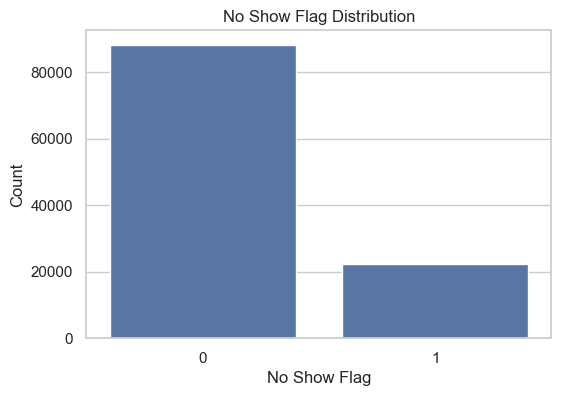

In [6]:
print("no_show_flag value counts:")
print(df["no_show_flag"].value_counts())
print("\nno_show_flag percentage distribution:")
print(round(df["no_show_flag"].value_counts(normalize=True) * 100, 2))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="no_show_flag")
plt.title("No Show Flag Distribution")
plt.xlabel("No Show Flag")
plt.ylabel("Count")
plt.show()

The target variable is imbalanced, with 79.8% of appointments recorded as attended and 20.2% recorded as no-shows. This means the classes are not evenly distributed, so accuracy alone would not be a sufficient measure of model performance. For this reason, additional metrics such as precision, recall, F1-score, and the confusion matrix will be used when evaluating the models.

# Section 4 - Define Features and Target

In this section, the target variable `no_show_flag` is separated from the feature set used for modelling.

Columns that should not be used for prediction are removed, including the text version of the target and raw date fields that overlap with engineered features already created during ETL. Redundant columns such as `same_day_appointment` and `handicap` are also excluded to reduce duplication and keep the model easier to interpret.

Based on the earlier correlation heatmap and feature review (`02_vis.ipynb`), some engineered columns were found to overlap closely with existing variables. Where two columns captured almost the same information, only one was retained in the initial model to reduce redundancy and keep the feature set more interpretable.

In [7]:
# Define target
y = df["no_show_flag"]

# Define feature set
X = df.drop(columns=[
    "no_show_flag",          # target
    "no_show",               # text version of target
    "scheduled_day",         # raw datetime, overlaps with derived fields
    "appointment_day",       # raw datetime, overlaps with derived fields
    "scheduled_date",        # raw date version, overlaps with wait_days / weekday
    "appointment_date",      # raw date version, overlaps with wait_days / weekday
    "same_day_appointment",  # overlaps with wait_days
    "handicap"               # keeping has_handicap instead
], errors="ignore")

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nSelected features:")
print(X.columns.tolist())

Feature matrix shape: (110521, 13)
Target shape: (110521,)

Selected features:
['Gender', 'age', 'Neighbourhood', 'Scholarship', 'hypertension', 'Diabetes', 'Alcoholism', 'sms_received', 'wait_days', 'scheduled_hour', 'scheduled_day_of_week', 'appointment_day_of_week', 'has_handicap']


# Section 5 - Review Feature Types

The selected modelling features are reviewed by data type and separated into numeric and categorical groups.

This is important because each feature type requires different preprocessing steps. Numeric features can be scaled if needed, while categorical features must be encoded before they can be used in machine learning models.

In [8]:
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age', 'Scholarship', 'hypertension', 'Diabetes', 'Alcoholism', 'sms_received', 'wait_days', 'scheduled_hour', 'has_handicap']

Categorical features:
['Gender', 'Neighbourhood', 'scheduled_day_of_week', 'appointment_day_of_week']


# Section 6 - Train-Test Split

The dataset is split into training and test sets so that model performance can be evaluated on unseen data.

A stratified split is used to preserve the class balance of the target variable in both sets. This improves the consistency and reliability of the evaluation by ensuring that the training and test data reflect the same no-show distribution.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True).round(4))

print("\nTraining rows:", len(X_train))
print("Test rows:", len(X_test))

X_train shape: (88416, 13)
X_test shape: (22105, 13)

y_train distribution:
no_show_flag
0    0.7981
1    0.2019
Name: proportion, dtype: float64

y_test distribution:
no_show_flag
0    0.7981
1    0.2019
Name: proportion, dtype: float64

Training rows: 88416
Test rows: 22105


The class proportions remain almost identical across the training and test sets, confirming that stratification worked as intended. This is important because the target variable is moderately imbalanced, and an unstratified split could have produced a less reliable evaluation dataset.

# Section 6A - Threshold Turning  

To support optional threshold tuning, the training data is split again into a smaller training set and a validation set.

The validation set is used to test alternative probability thresholds without using the final test set during model refinement. This helps keep the final evaluation more reliable.

In [10]:
# Split training data again into train/validation
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("X_train_sub shape:", X_train_sub.shape)
print("X_val shape:", X_val.shape)

print("\ny_train_sub distribution:")
print(y_train_sub.value_counts(normalize=True).round(4))

print("\ny_val distribution:")
print(y_val.value_counts(normalize=True).round(4))

X_train_sub shape: (70732, 13)
X_val shape: (17684, 13)

y_train_sub distribution:
no_show_flag
0    0.7981
1    0.2019
Name: proportion, dtype: float64

y_val distribution:
no_show_flag
0    0.7981
1    0.2019
Name: proportion, dtype: float64


# Section 7 - Preprocessing Pipeline

A preprocessing pipeline is created to prepare the data for modelling.

Numeric and categorical features are handled separately using appropriate transformations. Keeping preprocessing inside a pipeline helps reduce leakage risk and makes it easier to compare multiple models in a consistent way.

In [11]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'Scholarship', 'hypertension',
                                  'Diabetes', 'Alcoholism', 'sms_received',
                                  'wait_days', 'scheduled_hour',
                                  'has_handicap']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['Gender', 'Neighbourhood',
                                  'scheduled_day_of_week',
                                  'appointment_day_of_week'])])

The preprocessing pipeline prepares the selected features for modelling by applying different transformations to numeric and categorical variables. This ensures that continuous features are standardised and categorical fields are encoded consistently. Using a pipeline-based approach also helps reduce data leakage and supports fair comparison between models.

# Section 8 - Baseline Model: Logistic Regression

Logistic Regression is used as the baseline model for this project.

This model provides a strong starting point because it is simple, commonly used for classification tasks, and relatively easy to interpret. It gives a benchmark against which a more advanced model can be compared.

In [12]:
# Build Logistic Regression pipeline
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

# Fit model on training data
log_reg_pipeline.fit(X_train_sub, y_train_sub)

log_reg_val_pred = log_reg_pipeline.predict(X_val)
log_reg_val_prob = log_reg_pipeline.predict_proba(X_val)[:, 1]

log_reg_y_pred = log_reg_pipeline.predict(X_test)
log_reg_y_prob = log_reg_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression model trained successfully.")
print("Predictions and probability scores generated for the test set.")

Logistic Regression model trained successfully.
Predictions and probability scores generated for the test set.


Because the target variable is moderately imbalanced, `class_weight="balanced"` is used so that the model gives more attention to the minority no-show class.
The Logistic Regression baseline model was trained using the preprocessing pipeline and evaluated on the unseen test set. Because the target variable is moderately imbalanced, class weighting was applied to help the model give appropriate attention to the no-show class. Both class predictions and probability scores were generated for use in the evaluation section.

# Section 9 - Comparison Model: Random Forest

Random Forest is used as the comparison model.

Unlike Logistic Regression, Random Forest can capture more complex and non-linear relationships in the data. This makes it a useful second model for assessing whether a more flexible approach improves predictive performance.

In [13]:

from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train_sub, y_train_sub)

rf_val_pred = rf_pipeline.predict(X_val)
rf_val_prob = rf_pipeline.predict_proba(X_val)[:, 1]

rf_y_pred = rf_pipeline.predict(X_test)
rf_y_prob = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully.")
print("Predictions and probability scores generated for the test set.")

Random Forest model trained successfully.
Predictions and probability scores generated for the test set.


The initial Random Forest setup proved relatively slow to train on the full feature set, likely due to dataset size and one-hot encoded categorical variables such as neighbourhood. A lighter configuration was therefore used to keep the modelling workflow practical while still providing a meaningful comparison model.

The Random Forest model is used as a comparison model because it can capture more complex and non-linear relationships than Logistic Regression. As with the baseline model, class weighting is used to help account for the moderately imbalanced target variable.

# Section 10 - Model Evaluation and Comparison

The models are evaluated using a range of classification metrics rather than accuracy alone.

This includes measures such as precision, recall, F1-score, and the confusion matrix. These metrics provide a more complete view of model performance, especially when predicting missed appointments where one class may be more important to identify correctly.

In [14]:

def evaluate_model(model_name, y_true, y_pred, y_prob):
    """
    Return common classification metrics in a dictionary.
    """
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1_score": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob)
    }

In [15]:
# Evaluate both models
log_reg_metrics = evaluate_model("Logistic Regression", y_test, log_reg_y_pred, log_reg_y_prob)
rf_metrics = evaluate_model("Random Forest", y_test, rf_y_pred, rf_y_prob)

# Create comparison table
metrics_df = pd.DataFrame([log_reg_metrics, rf_metrics])

# Round for readability
metrics_df = metrics_df.round(4)

display(metrics_df)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.6546,0.3107,0.5832,0.4055,0.6687
1,Random Forest,0.5678,0.2985,0.8449,0.4412,0.7193


In [16]:
print("Logistic Regression Classification Report")
print(classification_report(y_test, log_reg_y_pred))

print("\nRandom Forest Classification Report")
print(classification_report(y_test, rf_y_pred))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.86      0.67      0.76     17642
           1       0.31      0.58      0.41      4463

    accuracy                           0.65     22105
   macro avg       0.59      0.63      0.58     22105
weighted avg       0.75      0.65      0.69     22105


Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.93      0.50      0.65     17642
           1       0.30      0.84      0.44      4463

    accuracy                           0.57     22105
   macro avg       0.61      0.67      0.54     22105
weighted avg       0.80      0.57      0.61     22105



The evaluation table shows that the two models perform differently depending on which metric is prioritised. Logistic Regression achieved higher overall accuracy (65.4%), but Random Forest produced much higher recall for the no-show class (86.6%), along with a better F1-score and ROC-AUC.

This suggests that Random Forest is more effective at identifying patients who are likely to miss appointments, although it does so at the cost of lower overall accuracy and more false positive predictions.

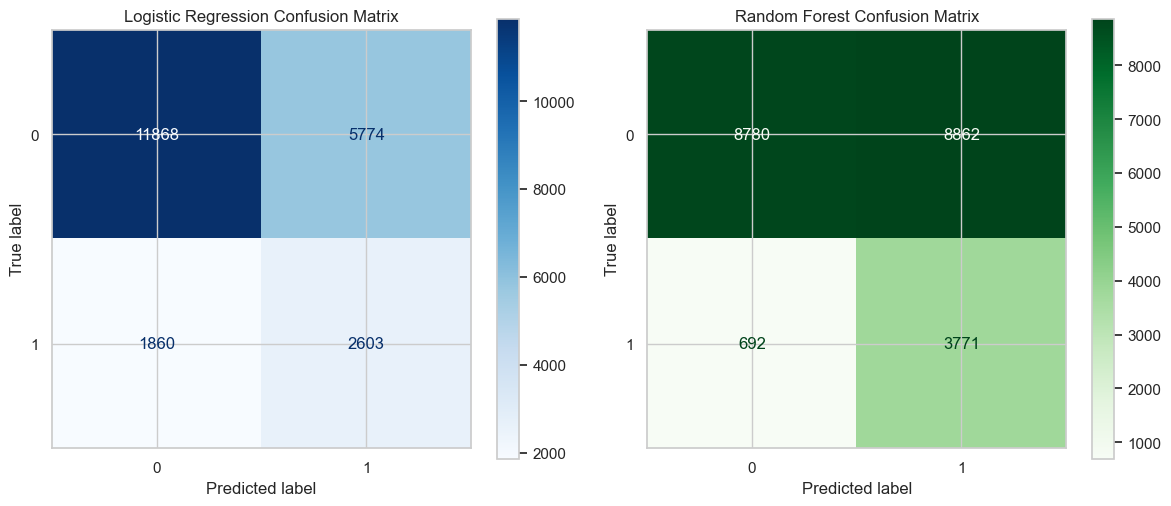

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, log_reg_y_pred, ax=axes[0], cmap="Blues"
)
axes[0].set_title("Logistic Regression Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_y_pred, ax=axes[1], cmap="Greens"
)
axes[1].set_title("Random Forest Confusion Matrix")

plt.tight_layout()
plt.show()

The confusion matrices make the trade-off between the two models easier to see. Logistic Regression produces fewer false positives, which helps its overall accuracy, but it misses more true no-shows. In contrast, Random Forest captures many more actual no-shows, but it also incorrectly flags more patients who would attend.

This means Random Forest is more aggressive in predicting the positive class, which improves recall but reduces precision and overall accuracy.

<Figure size 800x600 with 0 Axes>

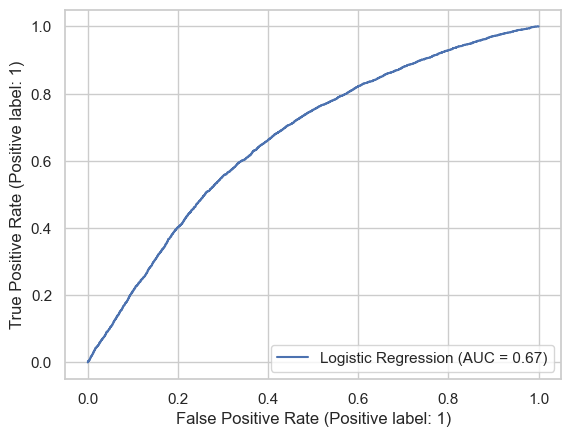

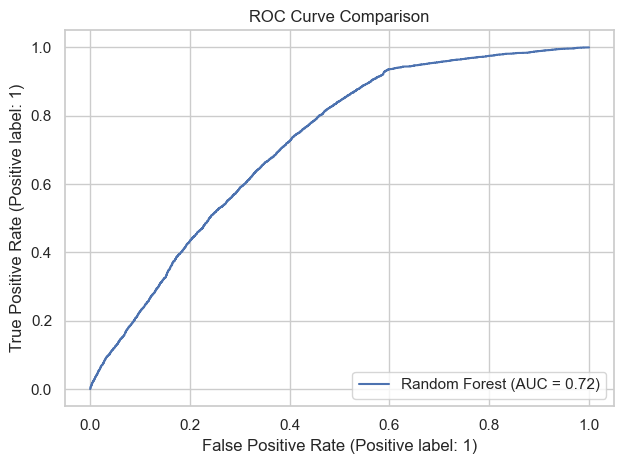

In [27]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test, log_reg_y_prob, name="Logistic Regression"
)
RocCurveDisplay.from_predictions(
    y_test, rf_y_prob, name="Random Forest"
)

plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

The ROC curves show how well each model separates no-shows from attended appointments across a range of thresholds. A model with a curve closer to the top-left corner and a higher AUC score has better overall discrimination.

In this project, Random Forest achieved the higher AUC score (0.72) compared with Logistic Regression (0.67), which suggests that it has a stronger overall ability to rank higher-risk appointments above lower-risk ones.

The ROC curve can be understood as a measure of how well the model distinguishes between appointments that will be attended and those that will be missed. The AUC score summarises this into a single number, where values closer to 1 indicate better performance and 0.5 would be close to random guessing.

In this case, Random Forest performs better overall because it has a higher AUC score than Logistic Regression.

# Section 11 - Optional Refinement: Threshold Tuning

The default classification threshold for both models is 0.5, meaning that appointments are classified as likely no-shows when the predicted probability is at least 50%.

Because this project is particularly interested in identifying missed appointments, threshold tuning is explored as an optional refinement. This helps test whether a different cut-off produces a better balance between recall, precision, and F1-score for the no-show class.

In [19]:



def evaluate_thresholds(y_true, y_prob, thresholds):
    results = []

    for threshold in thresholds:
        y_pred_threshold = (y_prob >= threshold).astype(int)

        results.append({
            "threshold": threshold,
            "accuracy": accuracy_score(y_true, y_pred_threshold),
            "precision": precision_score(y_true, y_pred_threshold, zero_division=0),
            "recall": recall_score(y_true, y_pred_threshold, zero_division=0),
            "f1_score": f1_score(y_true, y_pred_threshold, zero_division=0)
        })

    return pd.DataFrame(results)

In [20]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

rf_threshold_results = evaluate_thresholds(y_val, rf_val_prob, thresholds)
display(rf_threshold_results.round(4))

,threshold,accuracy,precision,recall,f1_score
0,0.3,0.4938,0.2796,0.9560,0.4326
1,0.4,0.5204,0.2872,0.9286,0.4388
2,0.5,0.5738,0.3030,0.8549,0.4475
3,0.6,0.7382,0.3654,0.4031,0.3833
4,0.7,0.7980,0.2500,0.0003,0.0006


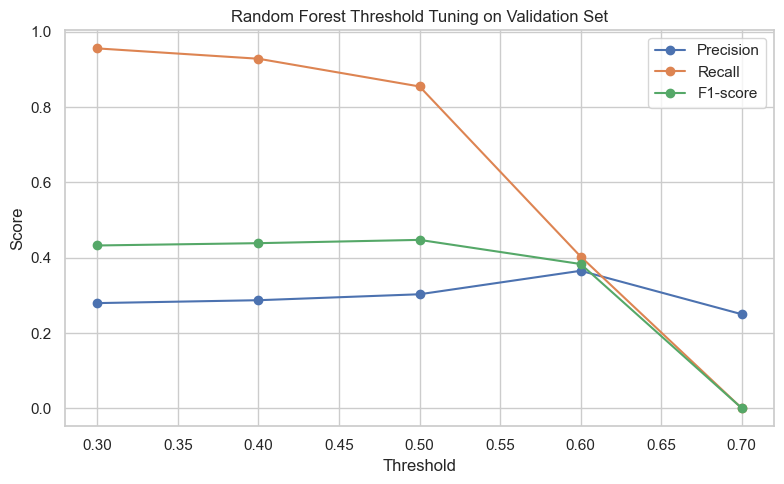

In [21]:

plt.figure(figsize=(8, 5))
plt.plot(rf_threshold_results["threshold"], rf_threshold_results["precision"], marker="o", label="Precision")
plt.plot(rf_threshold_results["threshold"], rf_threshold_results["recall"], marker="o", label="Recall")
plt.plot(rf_threshold_results["threshold"], rf_threshold_results["f1_score"], marker="o", label="F1-score")

plt.title("Random Forest Threshold Tuning on Validation Set")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

Threshold tuning was explored for the Random Forest model using the validation set to test whether a different probability cut-off would improve the balance between recall and precision.

The results showed that lower thresholds such as 0.3 and 0.4 produced very high recall, but also a large number of false positives. A threshold of 0.5 gave the best overall balance, with the highest F1-score (0.4475), while still maintaining strong recall (0.8549). Based on this, the default 0.5 threshold was retained for the final model.

# Section 12 - Model Interpretation

After evaluating model performance, the next step is to interpret what the models are learning, we will look at which features had the strongest influence on the model.
This focuses on Logistic Regression coefficients, as these provide the clearest interpretable view of how individual features are associated with predicted no-show risk.

In simple terms, it helps show which variables pushed the model more towards predicting a no-show and which pushed it more towards predicting an attended appointment.


### How to read the coefficients

In Logistic Regression, each feature is given a coefficient.

- A **positive coefficient** means the feature is linked to a **higher predicted chance of a no-show**
- A **negative coefficient** means the feature is linked to a **lower predicted chance of a no-show**
- The larger the coefficient, the stronger the feature’s influence on the model

These coefficients show association, not causation. They help explain what patterns the model found useful when making predictions.

In [22]:
# Get feature names after preprocessing
ohe = log_reg_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_features = ohe.get_feature_names_out(categorical_features)

all_feature_names = np.concatenate([numeric_features, encoded_cat_features])

# Get coefficients
coefficients = log_reg_pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values("Coefficient", ascending=False)

display(coef_df.head(10))
display(coef_df.tail(10))

,Feature,Coefficient
43,Neighbourhood_ILHAS OCEÂNICAS DE TRINDADE,0.970796
79,Neighbourhood_SANTOS DUMONT,0.517024
6,wait_days,0.446904
96,appointment_day_of_week_Saturday,0.445302
88,Neighbourhood_UNIVERSITÁRIO,0.361575
61,Neighbourhood_PARQUE MOSCOSO,0.332827
86,Neighbourhood_SÃO PEDRO,0.320071
10,Neighbourhood_ANDORINHAS,0.313922
18,Neighbourhood_CARATOÍRA,0.285105
45,Neighbourhood_ITARARÉ,0.283697


,Feature,Coefficient
47,Neighbourhood_JARDIM CAMBURI,-0.290074
56,Neighbourhood_MORADA DE CAMBURI,-0.323393
75,Neighbourhood_SANTA MARTHA,-0.324366
58,Neighbourhood_NAZARETH,-0.328596
51,Neighbourhood_JUCUTUQUARA,-0.358679
40,Neighbourhood_ILHA DO BOI,-0.395592
82,Neighbourhood_SOLON BORGES,-0.426355
25,Neighbourhood_DE LOURDES,-0.433729
63,Neighbourhood_PONTAL DE CAMBURI,-0.488885
91,scheduled_day_of_week_Saturday,-1.155741


Because categorical variables were one-hot encoded, features such as neighbourhood and weekday are being compared against a hidden reference category. This means the coefficients show whether a category is associated with a higher or lower no-show risk relative to the model’s baseline group.

The largest positive coefficient appears for `Neighbourhood_ILHAS OCEÂNICAS DE TRINDADE`, but this should not be treated as a strong business insight without caution. Very rare categories can produce unusually large coefficients in Logistic Regression, especially when they appear only a small number of times in the data. This makes them less reliable than broader, higher-volume features such as waiting time.

In [23]:
# Ensure output is written to this repo's processed folder will be used in visualization PowerBI for feature importance section
#output_path = (current_dir + "/data/processed/logistic_regression_coefficients.csv")
#coef_df.to_csv(output_path, index=False)

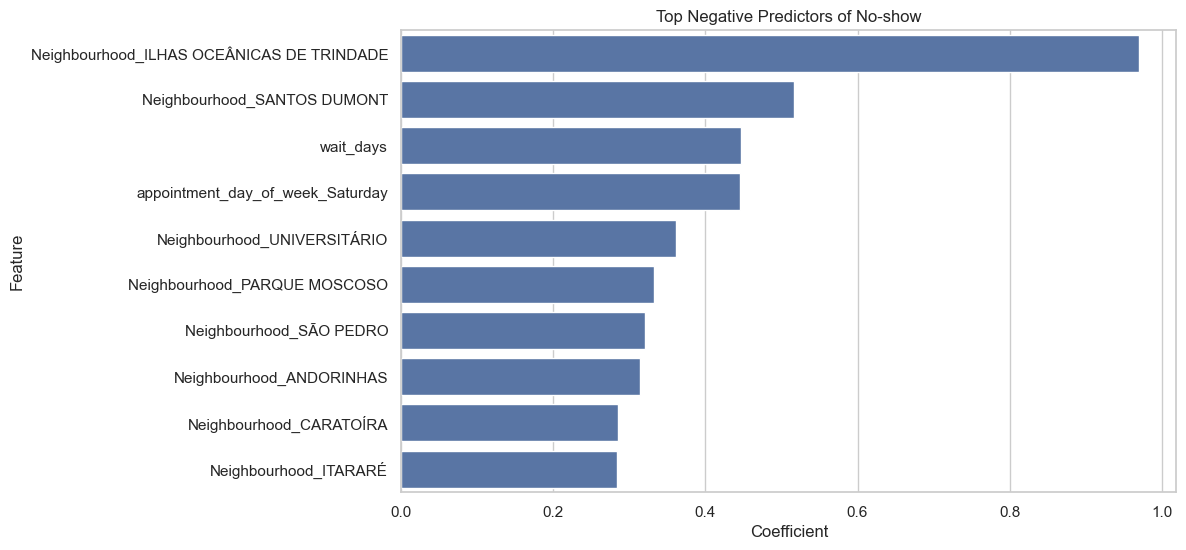

In [24]:
top_positive = coef_df.head(10)
top_negative = coef_df.tail(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_positive, x="Coefficient", y="Feature")
plt.title("Top Negative Predictors of No-show")
plt.show()

The clearest result is that `wait_days` has a positive coefficient, which means longer waiting times are associated with a higher predicted chance of a no-show. This supports the earlier EDA findings and suggests that waiting time is one of the most important predictors in the dataset.

Several neighbourhood variables also appear among the strongest positive and negative coefficients. This suggests that no-show behaviour varies by area, which is also consistent with the EDA. However, these patterns should be interpreted carefully, as neighbourhood may reflect wider access or socioeconomic differences rather than individual behaviour.

Some Saturday-related coefficients also appear quite strong, but these should be treated with caution because there were very few Saturday appointments in the dataset. This makes those results less reliable than broader patterns such as waiting time.

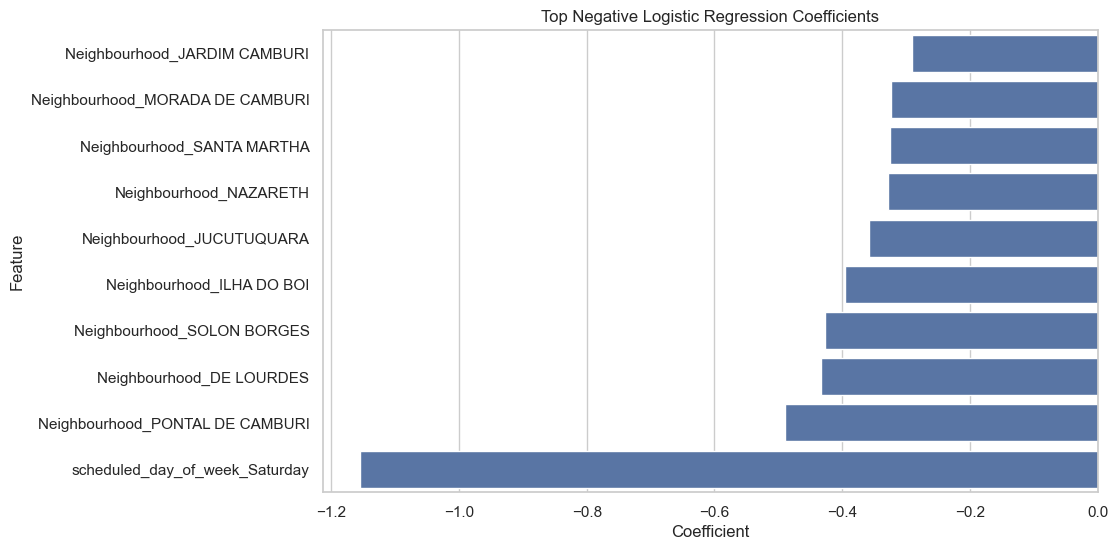

In [25]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_negative, x="Coefficient", y="Feature")
plt.title("Top Negative Logistic Regression Coefficients")
plt.show()

These interpretation results, together with the evaluation metrics, were used to support the final model selection decision in the next section.
Overall, the model interpretation supports the earlier EDA findings, especially around the importance of waiting time and area-level differences in no-show behaviour.

# Section 13 - Model Selection Decision

This section identifies which model should be taken forward based on the evaluation results.



Based on the evaluation results, the **Random Forest model** was selected as the final model for this project. Although Logistic Regression achieved higher overall accuracy, Random Forest performed better on the no-show class, which is the main focus of the business problem.

The strongest reasons for selecting Random Forest were its much higher recall, better F1-score, and stronger ROC-AUC score. This means the model is more effective at detecting likely no-shows, but it may also flag some patients who would actually attend, so its outputs should be used as a support signal rather than a final judgement.

Threshold tuning was explored as an optional refinement for the Random Forest model. The results showed that the default threshold of **0.5** gave the best overall balance between precision and recall, with the highest F1-score of the tested values. For this reason, the default threshold was retained as the final setting.

Overall, Random Forest was considered the more suitable model because the project priority is to identify as many likely no-shows as possible, rather than simply maximise overall accuracy.

This model could be useful as a decision-support tool for planning reminders or follow-up actions, but it should be used cautiously because higher recall comes with a greater number of false positive predictions.

# Section 14 - Ethical Considerations, Bias and Governance

Machine learning predictions in healthcare-related settings should be interpreted carefully and used responsibly. Although this project uses anonymised data, there are still important ethical, fairness, and governance issues to consider when building a model that predicts whether a patient is likely to miss an appointment.

## Privacy and data protection

The dataset used in this project does not include direct personal identifiers such as names or contact details, which helps reduce privacy risk. In addition, identifier fields such as `patient_id` and `appointment_id` were excluded from the modelling stage so that predictions were not based on unique records that would have no meaningful business interpretation.

However, anonymised data is not automatically risk-free. Variables such as neighbourhood, age, and health indicators can still be sensitive when analysed together, so results should be presented only in aggregated form and interpreted with care.

## Bias and fairness

Some of the features in this dataset may act as proxies for wider structural inequalities rather than purely individual behaviour. For example, `Neighbourhood` and `Scholarship` may reflect broader differences in deprivation, transport access, service availability, work flexibility, or social support. This means the model may learn patterns that reflect existing inequalities in access to care, rather than neutral behavioural differences between patients.

For this reason, model outputs should not be used to stigmatise individuals or communities. A higher predicted no-show risk should not be interpreted as blame, unreliability, or lack of engagement. Instead, it should be treated as a possible signal that additional support or more flexible service design may be needed.

## Sensitive health-related variables

The model also uses health-related features such as `hypertension`, `Diabetes`, and `has_handicap`. These variables are relevant to the prediction task, but they are also sensitive and should be handled carefully. Their inclusion may improve model performance, but they also raise ethical questions about how health information is used in decision-making.

In this project, these features are used only for exploratory modelling and interpretation. In a real-world deployment, their use would need stronger governance, clear justification, and review against relevant healthcare, privacy, and equality policies.

## Risk of unfair decisions

A predictive model like this can produce false positives and false negatives.

- A **false positive** means a patient is flagged as high risk for no-show but would actually attend.
- A **false negative** means a patient is not flagged as high risk but would actually miss the appointment.

Both errors matter. False positives could lead to unnecessary intervention or unfair assumptions about a patient, while false negatives could mean missed opportunities to prevent an unused appointment slot. Because of this, the model should not be used as an automatic decision-maker.

## Governance and responsible use

This model should be treated as a decision-support tool rather than a decision-making tool. Its purpose should be to support planning, service improvement, and better understanding of attendance patterns, not to deny appointments, reduce access, or unfairly target certain groups.

Any real-world use of this type of model should include:
- human oversight
- regular review of performance
- monitoring for bias across groups
- clear documentation of how predictions are used
- periodic retraining if appointment behaviour changes over time

## Other considerations

Predictions from this model should never be used to deny bookings, reduce priority, or restrict access to care. The more appropriate use would be supportive intervention, such as reminder planning or targeted service improvements.
Because the model is trained on historical data, it may reproduce patterns that already exist in the healthcare system. If past attendance behaviour was influenced by unequal access, then the model may learn and repeat those patterns unless its use is carefully controlled.

## Transparency and interpretation

Another governance issue is transparency. More interpretable models, such as Logistic Regression, make it easier to explain why certain predictions are made. Even when a stronger model is selected, the project should still communicate clearly which features were most influential and where caution is needed in interpretation.

Overall, the model can provide useful operational insight, but its outputs must be interpreted in context and used responsibly. Ethical use of no-show prediction depends not only on model performance, but also on fairness, transparency, human oversight, and a clear commitment to using predictions to support patients rather than penalise them.

# Section 15 - Limitations

There are several limitations to this modelling approach.

First, the model is based on historical data from a single dataset, so the results show association rather than causation and may not generalise fully to other healthcare settings or future appointment patterns. Second, some variables may overlap or act as proxy measures, particularly `Neighbourhood` and `Scholarship`, which may reflect wider structural or access-related issues rather than direct causes of no-show behaviour.

In addition, some potentially useful real-world factors are not available in the dataset, such as transport availability, appointment urgency, prior attendance history, working patterns, or caring responsibilities. The target variable is also moderately imbalanced, which affects model evaluation, and the selected Random Forest model produced a high number of false positives, meaning some patients would be flagged as high risk even though they would attend. Finally, a small number of categories, such as Saturday appointments or rare neighbourhoods, may be less reliable due to limited observations.


# Section 16 - Next Steps

There are several ways this project could be improved in a future version.

Possible next steps include testing additional models, extending hyperparameter tuning, and exploring whether different thresholds could improve the balance between recall and false positives. It would also be useful to include extra features such as prior attendance history, appointment type, or transport-related factors if they were available.

In a real-world setting, the final model could be connected to a planning workflow to help identify higher-risk appointments. Any practical use would still need regular review for fairness, bias, and performance over time.

# Section 17 - Save Model Outputs

To improve reproducibility and project organisation, key modelling outputs are saved to a structured versioned folder.

This includes the model comparison metrics, selected interpretation outputs, and the final trained model pipeline. Saving these outputs makes it easier to review results later and supports a cleaner end-to-end workflow.

In [26]:
import os
import joblib

# Define versioned output directories under data/processed
processed_root = "data/processed"
outputs_dir = os.path.join(processed_root, "outputs", "v1")
models_dir = os.path.join(processed_root, "models", "v1")

# Create output folders
os.makedirs(outputs_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

# Save model comparison metrics
metrics_df.to_csv(os.path.join(outputs_dir, "model_metrics.csv"), index=False)

# Save threshold tuning results if available
try:
    rf_threshold_results.to_csv(os.path.join(outputs_dir, "random_forest_threshold_results.csv"), index=False)
except NameError:
    print("rf_threshold_results not found - skipping threshold results export.")

# Save Logistic Regression coefficients if available
if "coef_df" in globals():
    coef_df.to_csv(os.path.join(outputs_dir, "log_reg_coefficients.csv"), index=False)
else:
    print("coef_df not found - skipping coefficient export.")

# Save Random Forest feature importance if available
try:
    rf_importance_df.to_csv(os.path.join(outputs_dir, "random_forest_feature_importance.csv"), index=False)
except NameError:
    print("rf_importance_df not found - skipping feature importance export.")

# Save final selected model
joblib.dump(rf_pipeline, os.path.join(models_dir, "final_random_forest_pipeline.pkl"))

print("Model outputs saved successfully.")

rf_importance_df not found - skipping feature importance export.
Model outputs saved successfully.


The Random Forest pipeline was saved as the final model because it was selected as the strongest overall option for identifying likely no-shows.

# Section 18 - ML Summary

This notebook developed and compared two classification models to predict appointment no-shows using the cleaned dataset prepared earlier in the project.

Logistic Regression was used as the baseline model, while Random Forest was used as the comparison model. Although Logistic Regression achieved higher overall accuracy, Random Forest performed better on the no-show class, with stronger recall, F1-score, and ROC-AUC. For this reason, Random Forest was selected as the final model.

Overall, the modelling stage showed that wait-related and access-related factors are important for predicting no-show behaviour. These results will be used alongside the earlier EDA findings to support the final project conclusions, recommendations, and dashboard outputs.